In [1]:
import os
import json
import random
from pathlib import Path
import numpy as np
from types import SimpleNamespace
import torch


import sys
repo_root = Path(os.getcwd())
if str(repo_root) not in sys.path:
    sys.path.insert(0, str(repo_root))

from loader import Loader

N = 205942
seed = 0

random.seed(seed)
np.random.seed(seed)

# Loader の初期化はプロジェクトの使い方に合わせて調整してください。
# ここではデフォルトの設定ファイル名を渡して Loader を作る例を示します。

args = SimpleNamespace(
	adv_cfg_path='config.simpl_cfg',  # ← module path (no .py)
	features_dir=str(Path.cwd() / 'data_argo/features') + '/',  # ← 実際の features ディレクトリに合わせて
	mode='train',
	data_aug=False
)

device = torch.device('cpu')

loader = Loader(args, device, is_ddp=False)
(train_set, _), net, loss_fn, optimizer, evaluator = loader.load()

# total = len(train_set)
# if N >= total:
#     indices = list(range(total))
# else:
#     indices = random.sample(range(total), N)

# samples = [train_set[i] for i in indices]

/home/tucker/miniconda3/envs/simpl-py39/lib/python3.9/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


[Loader] load adv_cfg from config.simpl_cfg
[Loader] load dataset ArgoDataset from simpl.av1_dataset
[Dataset] preparing /home/tucker/dev/SIMPL/data_argo/features/train/
[Dataset] Dataset Info:
-- mode:  train
-- total frames:  205942
-- obs_len:  20
-- pred_len:  30
-- seq_len:  50
-- aug:  False
[Dataset] preparing /home/tucker/dev/SIMPL/data_argo/features/val/
[Dataset] Dataset Info:
-- mode:  val
-- total frames:  39472
-- obs_len:  20
-- pred_len:  30
-- seq_len:  50
-- aug:  False
[Loader] load network Simpl from simpl.simpl
[Loader] network params:
-- total: 1827965
-- pred_net 422461
-- fusion_net 813696
-- actor_net 422720
-- lane_net 169088
[Loader] loading loss LossFunc from simpl.av1_loss_fn


In [12]:
type(samples)

list

In [13]:
samples[0]

{'SEQ_ID': 193424,
 'CITY_NAME': 'MIA',
 'ORIG': array([ 131.94716, 3017.1562 ], dtype=float32),
 'ROT': array([[ 0.04045999,  0.99918115],
        [-0.99918115,  0.04045999]], dtype=float32),
 'TRAJS_OBS': array([[[-2.32939758e+01,  0.00000000e+00],
         [-2.13718948e+01, -8.80782902e-02],
         [-2.05004787e+01, -1.15881667e-01],
         [-1.96933594e+01, -1.14341490e-01],
         [-1.77945919e+01, -1.50683314e-01],
         [-1.70911636e+01, -1.81503922e-01],
         [-1.61320515e+01, -2.15851590e-01],
         [-1.46648741e+01, -1.63766518e-01],
         [-1.36103811e+01, -1.47687048e-01],
         [-1.29947147e+01, -1.32007170e+00],
         [-1.12121944e+01, -1.96356654e-01],
         [-1.03491459e+01, -2.49751940e-01],
         [-8.62602234e+00, -2.36863181e-01],
         [-7.82213354e+00, -2.60817438e-01],
         [-6.09246445e+00, -2.43184686e-01],
         [-5.31458092e+00, -2.93864369e-01],
         [-3.43559003e+00, -1.97033808e-01],
         [-2.56638503e+00, -2

In [22]:
def overview(d):
    for k, v in d.items():
        if hasattr(v, "shape"):
            print(f"{k:12} | {type(v).__name__:<12} shape={v.shape} dtype={getattr(v, 'dtype', '-')}") 
        else:
            print(f"{k:12} | {type(v).__name__:<12} value={v}")


In [23]:
sample = samples[0]
overview(sample)

SEQ_ID       | int64        shape=() dtype=int64
CITY_NAME    | str          value=MIA
ORIG         | ndarray      shape=(2,) dtype=float32
ROT          | ndarray      shape=(2, 2) dtype=float32
TRAJS_OBS    | ndarray      shape=(23, 20, 2) dtype=float32
TRAJS_FUT    | ndarray      shape=(23, 30, 2) dtype=float32
PAD_OBS      | ndarray      shape=(23, 20) dtype=int16
PAD_FUT      | ndarray      shape=(23, 30) dtype=int16
TRAJS_CTRS   | ndarray      shape=(23, 2) dtype=float32
TRAJS_VECS   | ndarray      shape=(23, 2) dtype=float32
LANE_GRAPH   | dict         value={'node_ctrs': array([[[-4.9758220e+00,  2.3247596e-04],
        [-3.8700838e+00,  1.1623917e-04],
        [-2.7643456e+00,  2.3872206e-09],
        ...,
        [ 2.7643456e+00, -7.2652168e-05],
        [ 3.8700838e+00,  7.2646442e-05],
        [ 4.9758220e+00,  2.1794505e-04]],

       [[-4.9758172e+00,  8.7655401e-08],
        [-3.8700838e+00,  2.1934144e-03],
        [-2.7643464e+00,  1.9191414e-03],
        ...,
        [

In [2]:
import numpy as np
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler
import matplotlib.pyplot as plt

def scenario_to_vector(sample, max_agents=32, T_obs=20, T_fut=30):
    """
    sample(dict) -> 1D numpy array (fixed length)
    - 変動するエージェント数を max_agents にクリップ/ゼロ埋め
    - PAD_OBS/PAD_FUT がある前提で無効フレームは 0 に
    """
    obs = sample["TRAJS_OBS"]        # (N, T_obs, 2)
    fut = sample["TRAJS_FUT"]        # (N, T_fut, 2)
    pad_obs = sample["PAD_OBS"]      # (N, T_obs)
    pad_fut = sample["PAD_FUT"]      # (N, T_fut)

    N = obs.shape[0]
    N_use = min(N, max_agents)

    # 無効フレームを 0 に（True=1 なら反転必要かも。あなたのデータに合わせて調整）
    # ここでは 1=パディング と仮定して 1 のところを 0 値に落とす
    obs_mask = (pad_obs[:N_use] == 0)[..., None]  # (N_use, T_obs, 1)
    fut_mask = (pad_fut[:N_use] == 0)[..., None]  # (N_use, T_fut, 1)

    obs_use = np.zeros((max_agents, T_obs, 2), dtype=np.float32)
    fut_use = np.zeros((max_agents, T_fut, 2), dtype=np.float32)

    obs_use[:N_use] = obs[:N_use] * obs_mask
    fut_use[:N_use] = fut[:N_use] * fut_mask

    # 位置の原点・回転は既に ORIG/ROT で正規化済み想定（必要なら to_local してから）
    # ベクトル化（固定長）
    vec = np.concatenate([
        obs_use.reshape(max_agents * T_obs * 2),
        fut_use.reshape(max_agents * T_fut * 2),
        np.array([N], dtype=np.float32),                 # エージェント数を1次元足す
    ], axis=0)

    return vec

In [3]:
len(train_set)

205942

In [ ]:
# ---- データをベクトル化して PCA ----
# samples: あなたのデータの list[dict]
X = np.stack([scenario_to_vector(s, max_agents=32, T_obs=20, T_fut=30) for s in train_set], axis=0)

scaler = StandardScaler()
Xn = scaler.fit_transform(X)

pca = PCA(n_components=2, random_state=0)
Z = pca.fit_transform(Xn)

print("Explained variance ratio:", pca.explained_variance_ratio_)


Explained variance ratio: [0.02048273 0.01360386]


NameError: name 'samples' is not defined

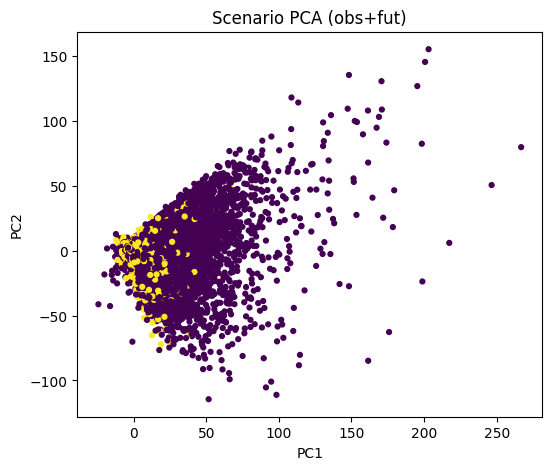

In [5]:
# 可視化（都市ごと色分けの例）
cities = [s["CITY_NAME"] for s in train_set]
uniq = sorted(set(cities))
color_map = {c:i for i,c in enumerate(uniq)}
c = [color_map[x] for x in cities]

plt.figure(figsize=(6,5))
plt.scatter(Z[:,0], Z[:,1], s=12, c=c)
plt.xlabel("PC1"); plt.ylabel("PC2"); plt.title("Scenario PCA (obs+fut)")
plt.show()